In [11]:
import duckdb
import matplotlib.pyplot as plt
from medicaid_spending.config import PARQUET_PATH
import numpy as np
import pandas as pd

con = duckdb.connect()

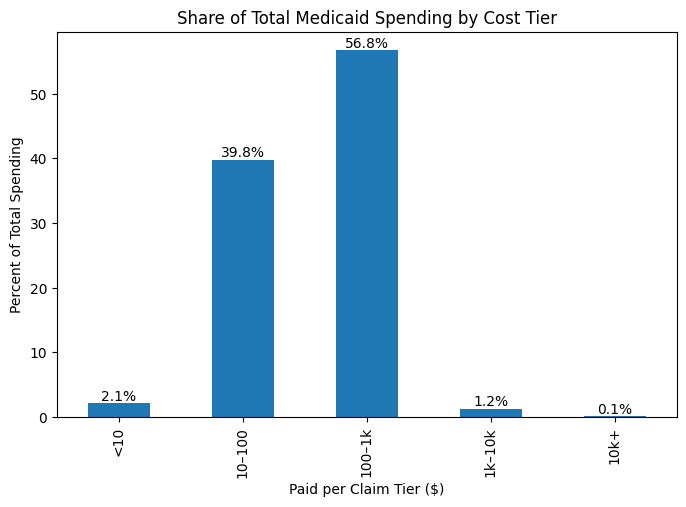

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from medicaid_spending.config import PARQUET_PATH

con = duckdb.connect()

# 1) Aggregate to HCPCS level
hcpcs_cost = con.execute("""
    SELECT
        HCPCS_CODE,
        SUM(TOTAL_PAID) AS total_paid,
        SUM(TOTAL_CLAIMS) AS total_claims,
        SUM(TOTAL_PAID) / SUM(TOTAL_CLAIMS) AS paid_per_claim
    FROM read_parquet(?)
    GROUP BY HCPCS_CODE
    HAVING SUM(TOTAL_CLAIMS) > 10000
""", [str(PARQUET_PATH)]).df()

# 2) Assign tiers
bins = [0, 10, 100, 1000, 10000, 100000]
labels = ["<10", "10–100", "100–1k", "1k–10k", "10k+"]

hcpcs_cost["tier"] = pd.cut(
    hcpcs_cost["paid_per_claim"],
    bins=bins,
    labels=labels
)

# 3) Spending per tier
tier_spend = (
    hcpcs_cost
    .groupby("tier", observed=True)["total_paid"]
    .sum()
    .reindex(labels)  # keeps order stable
)

# 4) Convert to share
tier_share = tier_spend / tier_spend.sum()

tier_share

plt.figure(figsize=(8,5))
ax = (tier_share * 100).plot(kind="bar")

plt.title("Share of Total Medicaid Spending by Cost Tier")
plt.xlabel("Paid per Claim Tier ($)")
plt.ylabel("Percent of Total Spending")

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom")

plt.savefig("images/paid_per_claim_outliers.png", bbox_inches="tight")

plt.show()
